# Induced-EQ Forecasting Analysis

Modified from *Using Deep Learning for Flexible and Scalable Earthquake Forecasting*.
Reference: [Zenodo](https://zenodo.org/records/8161777)

## 1) Setup

In [4]:
import os
import sys
import functools
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import json


def resolve_project_root() -> Path:
    cwd = Path.cwd().resolve()
    for candidate in (cwd, cwd.parent):
        if (candidate / 'src').exists():
            return candidate
    raise FileNotFoundError("Cannot find project root containing 'src' directory.")


PROJECT_ROOT = resolve_project_root()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

import src
import src.catalogs as catalogs
import src.utils.catalog_tests as catalog_tests
from src.models.tpp import etas, etas_zhuang, recurrent
from src.train.config_setup import load_and_prepare_model
from src.utils.forecast_eval import (
    apply_publication_style,
    evaluate_sliding_window_forecast_plots,
    save_pub_figure,
    style_current_figure,
    )
from src.utils.tpp_experiments import load_tpp_catalog, sample_tpp_forecasts
from src.utils.utils import set_seed
from src.utils.viz_sequences import visualize_sequence, visualize_trajectories, plot_intensity

apply_publication_style()

os.environ['CUDA_LAUNCH_BLOCKING'] = '1'
set_seed(0)
DEVICE = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')

print(f'PROJECT_ROOT: {PROJECT_ROOT}')
print(f'DEVICE: {DEVICE}')

PROJECT_ROOT: /root/autodl-tmp/em_eqf
DEVICE: cuda:0


## 2) Configuration

In [5]:
CHECKPOINT_DIR = PROJECT_ROOT / 'checkpoints/rtpp_20260409-223129'
CHECKPOINT_PATH = CHECKPOINT_DIR / 'best_model_1.pth'

# Optional: replace current background model with another checkpoint's background model.
USE_ALT_BG_MODEL = False
ALT_BG_CHECKPOINT_PATH = PROJECT_ROOT / 'checkpoints' / 'etas_20251221-224107' / 'best_model_1.pth'

USE_TORCH_COMPILE = True
MODEL_MM = 6.5  # set to None to skip overriding model.M_m

print(f'CHECKPOINT_PATH: {CHECKPOINT_PATH}')

CHECKPOINT_PATH: /root/autodl-tmp/em_eqf/checkpoints/rtpp_20260409-223129/best_model_1.pth


## 3) Load Model and Catalog

In [6]:
from src.utils.runtime_utils import unwrap_compiled_model

model, args = load_and_prepare_model(
    checkpoint_path=CHECKPOINT_PATH,
    device=DEVICE,
    compile=USE_TORCH_COMPILE,
)
model = unwrap_compiled_model(model)

if USE_ALT_BG_MODEL:
    alt_model, _ = load_and_prepare_model(
        checkpoint_path=ALT_BG_CHECKPOINT_PATH,
        device=DEVICE,
        compile=False,
    )
    alt_model = unwrap_compiled_model(alt_model)
    if getattr(alt_model, 'bg_model', None) is not None:
        model.bg_model = alt_model.bg_model
    del alt_model

if MODEL_MM is not None and hasattr(model, 'M_m'):
    model.M_m = torch.tensor(float(MODEL_MM), device=DEVICE)

if getattr(model, 'bg_model', None) is not None:
    print(f'background scale: {model.bg_model._scale}')

if hasattr(model, 'print_params'):
    model.print_params()

background scale: 870.2588500976562


Using catalog registry name: CB_HAB4-Standard


<Axes: xlabel='Arrival time (days)', ylabel='Magnitude'>

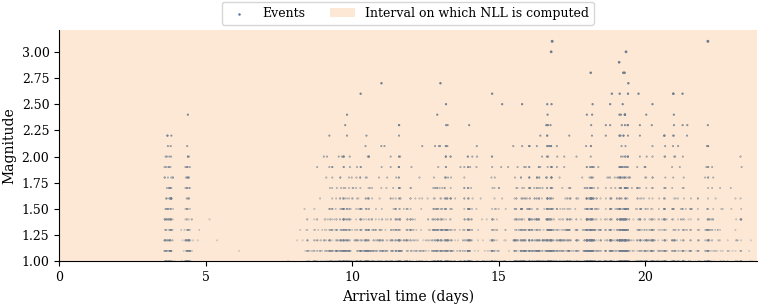

In [7]:
catalog_cfg = getattr(args, 'catalog_cfg', {})
catalog_ds, registry_name, catalog_init_kwargs = load_tpp_catalog(
    args.dataset,
    base_dir=PROJECT_ROOT / 'data' / args.dataset,
    catalog_cfg=catalog_cfg,
)
print(f'Using catalog registry name: {registry_name}')

metadata = catalog_ds.metadata
if  hasattr(metadata, 'start_ts') and hasattr(metadata, 'val_start_ts') and hasattr(metadata, 'test_start_ts') and hasattr(metadata, 'freq'):
    start_ts = pd.to_datetime(metadata['start_ts'])
    val_start_ts = pd.to_datetime(metadata['val_start_ts'])
    test_start_ts = pd.to_datetime(metadata['test_start_ts'])
    freq_td = pd.to_timedelta(metadata['freq'])

    print(f'Model: {args.model} | Dataset: {args.dataset}')
    print(f'train end index: {(val_start_ts - start_ts) / freq_td}')
    print(f'val end index: {(test_start_ts - start_ts) / freq_td}')

full_seq = catalog_ds.full_sequence
sequences = catalog_ds.sequences if hasattr(catalog_ds, 'sequences') else [full_seq]

visualize_sequence(full_seq, show_nll=True)

In [8]:
if hasattr(model, 'effective_branching_ratio'):
   print(f'branching ratio: {model.effective_branching_ratio()}')

In [9]:
# model.bg_model.stochastic_eval = False

In [10]:
catalog_ds.metadata

{'name': 'CB_HAB4',
 'freq': '1D',
 'freq_min': 1,
 'mag_roundoff_error': 0.01,
 'mag_completeness': 0.9,
 'start_ts': Timestamp('2012-11-10 12:21:28'),
 'end_ts': Timestamp('2012-12-04 07:29:28'),
 'train_start_ts': Timestamp('2012-11-10 12:21:28'),
 'val_start_ts': Timestamp('2012-11-28 12:00:00'),
 'test_start_ts': Timestamp('2012-11-30 00:00:00'),
 'start_t': 0.0,
 'end_t': 23.79722222222222,
 'train_start_t': 0.0,
 'val_start_t': 17.985092592592594,
 'test_start_t': 19.485092592592594,
 'inj_fill_policy': 'aggregate_mean',
 'is_upsample': False}

## 4) Batch and Intensity Diagnostics

In [11]:
def sequence_to_batch(seq, device):
    batch = src.data.Batch.from_list([seq])
    return batch.to(device)

SEQUENCE_IDX = 0
seq = sequences[SEQUENCE_IDX]
batch = sequence_to_batch(seq, DEVICE)

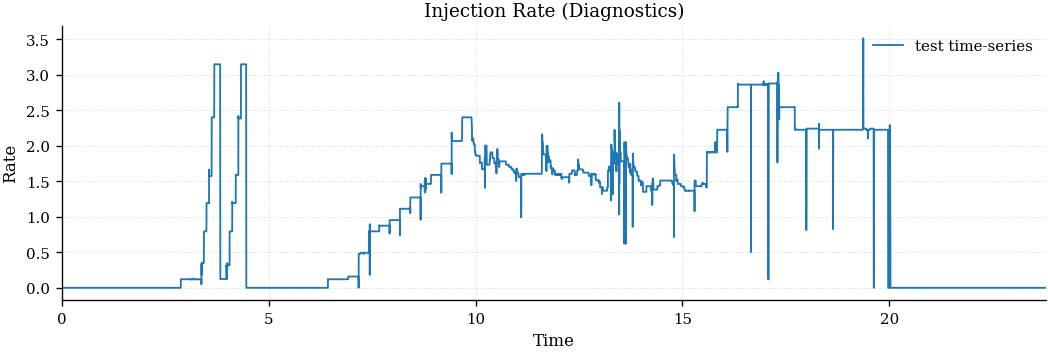

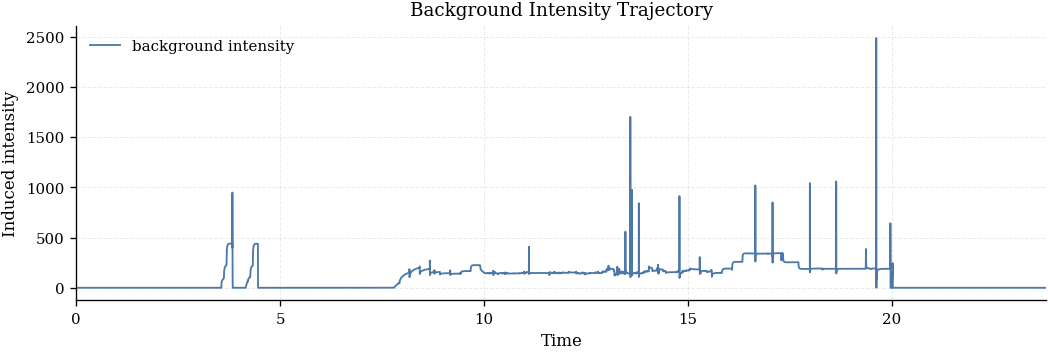

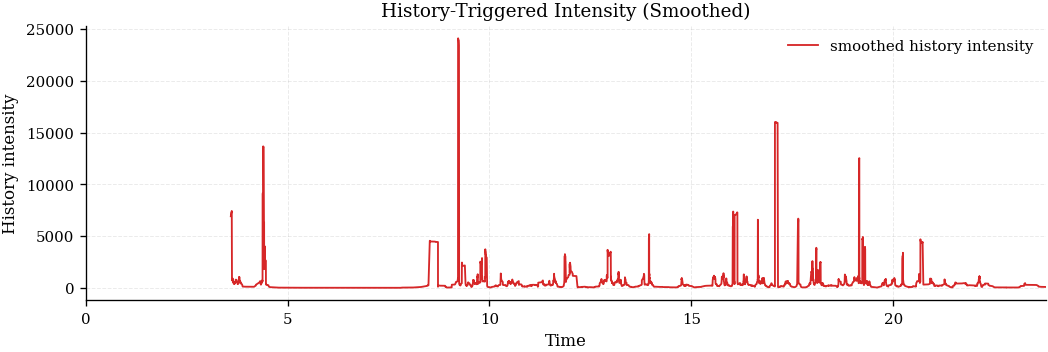

count(h_intensity > 1000): 920


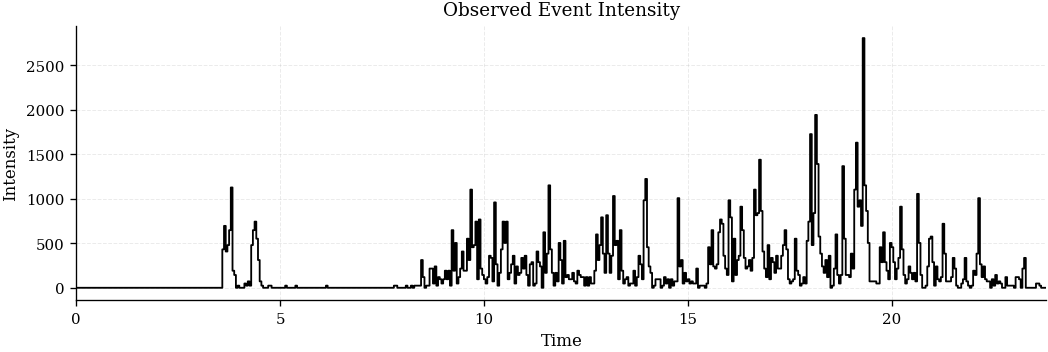

In [12]:
diag_times = batch.time_series_times.reshape(-1)
if diag_times.numel() > 0:
    diag_start = float(diag_times.min().item())
    diag_end = float(diag_times.max().item())
else:
    diag_start = float(seq.t_start)
    diag_end = float(seq.t_end)

diag_colors = {
    'series': '#1f77b4',
    'bg': '#4c78a8',
    'hist': '#d62728',
    'hawkes': '#ff7f0e',
}

def _apply_diag_axis(ax, xlabel='Time', ylabel=None, title=None):
    ax.set_xlim(diag_start, diag_end)
    ax.set_xlabel(xlabel)
    if ylabel is not None:
        ax.set_ylabel(ylabel)
    if title is not None:
        ax.set_title(title)
    ax.grid(True, alpha=0.25, linestyle='--', linewidth=0.6)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

fig, ax = plt.subplots(figsize=(9, 3.2))
ax.plot(
    batch.time_series_times.squeeze().detach().cpu().numpy(),
    batch.time_series.squeeze().detach().cpu().numpy(),
    linewidth=1.1,
    color=diag_colors['series'],
    label='test time-series',
)
_apply_diag_axis(ax, ylabel='Rate', title='Injection Rate (Diagnostics)')
ax.legend(frameon=False)
fig.tight_layout()
save_pub_figure(fig, CHECKPOINT_DIR / 'diagnostic_injection_rate.png')
plt.show()

if getattr(model, 'bg_model', None) is not None:
    f_intensity_trajectory = model.bg_model.intensity_trajectory(batch)
    fig, ax = plt.subplots(figsize=(9, 3.2))
    ax.plot(
        batch.time_series_times.squeeze().detach().cpu().numpy(),
        f_intensity_trajectory.squeeze().detach().cpu().numpy(),
        linewidth=1.1,
        color=diag_colors['bg'],
        label='background intensity',
    )
    _apply_diag_axis(ax, ylabel='Induced intensity', title='Background Intensity Trajectory')
    ax.legend(frameon=False)
    fig.tight_layout()
    save_pub_figure(fig, CHECKPOINT_DIR / 'induced_intensity.png')
    plt.show()

if isinstance(model, recurrent.RecurrentTPP):
    context = model.get_context(batch)
    inter_time_dist = model.get_inter_time_dist(context)
    log_h = inter_time_dist.log_hazard(batch.inter_times.clamp_min(1e-10))
    h_intensity = torch.exp(log_h)
    h_intensity = torch.where(h_intensity > 500000, torch.tensor(0.0, device=h_intensity.device), h_intensity)

    window = 20
    arrival_times_np = batch.arrival_times.detach().cpu().numpy().ravel()
    raw_np = h_intensity.detach().cpu().numpy().ravel()
    smoothed = np.convolve(raw_np, np.ones(window) / window, mode='same')

    fig, ax = plt.subplots(figsize=(9, 3.2))
    ax.plot(
        arrival_times_np,
        smoothed,
        linewidth=1.1,
        color=diag_colors['hist'],
        label='smoothed history intensity',
    )
    _apply_diag_axis(ax, ylabel='History intensity', title='History-Triggered Intensity (Smoothed)')
    ax.legend(frameon=False)
    fig.tight_layout()
    save_pub_figure(fig, CHECKPOINT_DIR / 'history_intensity_smoothed.png')
    plt.show()

    print('count(h_intensity > 1000):', int((h_intensity > 1000).sum().item()))
elif isinstance(model, (etas.ETAS, etas_zhuang.ETASZhuang)):
    h_intensity = model.h_intensity(batch)
    fig, ax = plt.subplots(figsize=(9, 3.2))
    ax.plot(
        batch.arrival_times.reshape(-1)[:-1].detach().cpu().numpy(),
        h_intensity.reshape(-1).detach().cpu().numpy(),
        linewidth=1.1,
        color=diag_colors['hawkes'],
    )
    _apply_diag_axis(ax, ylabel='Hawkes intensity', title='Hawkes Intensity')
    fig.tight_layout()
    save_pub_figure(fig, CHECKPOINT_DIR / 'hawkes_intensity.png')
    plt.show()

fig, ax = plt.subplots(figsize=(9, 3.2))
plot_intensity(seq, dt=1/24, ax=ax, T0=diag_start, T=diag_end)
_apply_diag_axis(ax, ylabel='Intensity', title='Observed Event Intensity')
fig.tight_layout()
save_pub_figure(fig, CHECKPOINT_DIR / 'observed_event_intensity.png')
plt.show()


## 5) Single-Window Forecast

In [13]:
# Single forecast window settings
T_FORECAST = 15
FORECAST_DURATION = 1
NUM_SAMPLES = 1000
SAMPLES_PER_BATCH = 1000

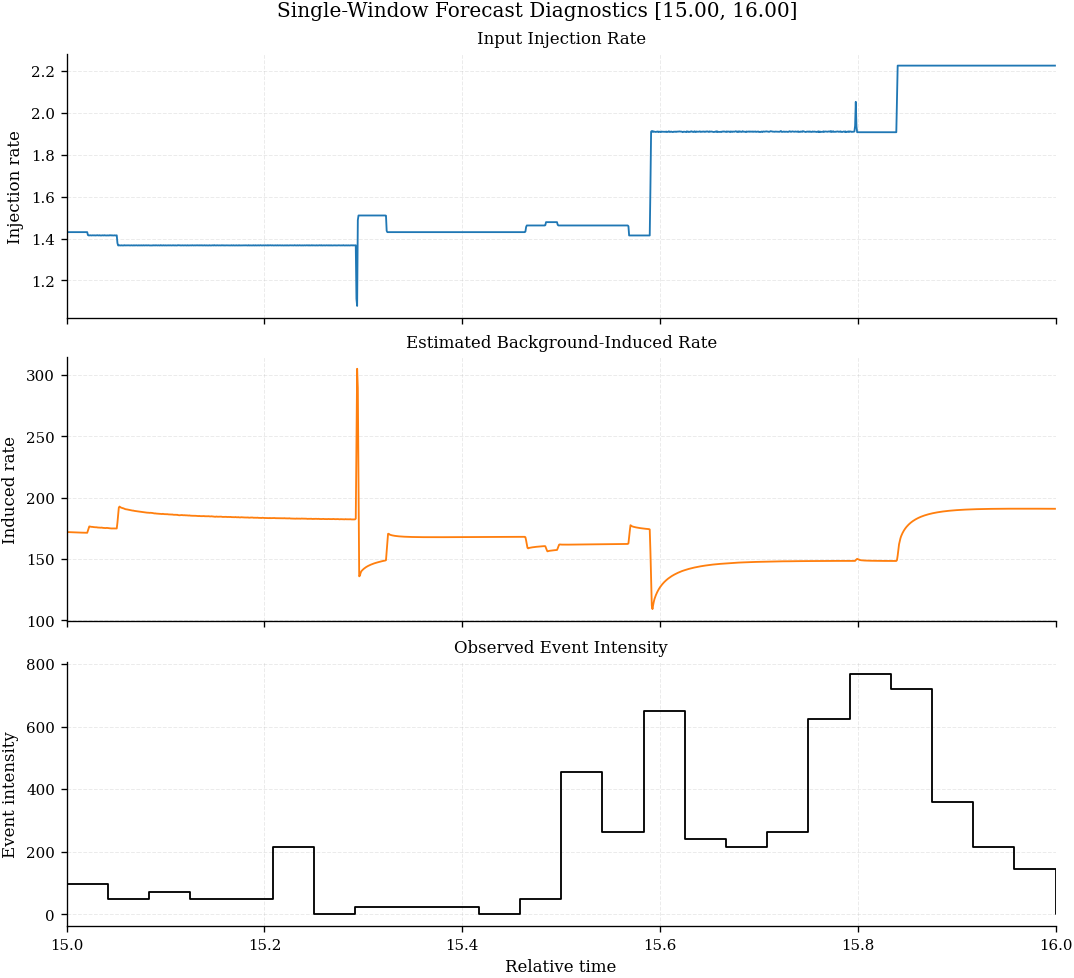

Background forecast count in [15, 16]: 168.9578857421875
Observed events in window: 232


In [14]:
past_seq = seq.get_subsequence(0, T_FORECAST, reset_t_nll_to_end=True)
observed_seq = seq.get_subsequence(T_FORECAST, T_FORECAST + FORECAST_DURATION, reset_t_nll_to_end=True)

window_start = float(T_FORECAST)
window_end = float(T_FORECAST + FORECAST_DURATION)

mask_future = (seq.time_series_times >= window_start) & (seq.time_series_times < window_end)
future_time_series = seq.time_series[mask_future]
future_time_series_times = seq.time_series_times[mask_future]

window_colors = {
    'inj': '#1f77b4',
    'bg': '#ff7f0e',
    'obs': '#2ca02c',
}

def _apply_window_axis(ax, ylabel=None, title=None, show_xlabel=False):
    ax.set_xlim(window_start, window_end)
    if show_xlabel:
        ax.set_xlabel('Relative time')
    if ylabel is not None:
        ax.set_ylabel(ylabel)
    if title is not None:
        ax.set_title(title, fontsize=10)
    ax.grid(True, alpha=0.25, linestyle='--', linewidth=0.6)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

if getattr(model, 'bg_model', None) is not None:
    model.bg_model.cache_batch(
        time_series=seq.time_series.unsqueeze(0),
        time_series_times=seq.time_series_times.unsqueeze(0),
    )
    times_all = seq.time_series_times
    window_mask = (times_all >= window_start) & (times_all < window_end)
    window_times = times_all[window_mask]
    f_intensity = model.bg_model.intensity(
        ts_batch=model.bg_model.ts_batch_cache,
        t_query=window_times.unsqueeze(0),
    )

    fig, (ax_inj, ax_bg, ax_obs) = plt.subplots(
        3, 1, figsize=(9, 8.2), sharex=True, constrained_layout=True
    )
    fig.suptitle(f'Single-Window Forecast Diagnostics [{window_start:.2f}, {window_end:.2f}]', fontsize=12)

    ax_inj.plot(
        future_time_series_times.detach().cpu().numpy(),
        future_time_series.reshape(-1).detach().cpu().numpy(),
        linewidth=1.1,
        color=window_colors['inj'],
    )
    _apply_window_axis(
        ax_inj,
        ylabel='Injection rate',
        title='Input Injection Rate',
    )

    ax_bg.plot(
        window_times.detach().cpu().numpy(),
        f_intensity.reshape(-1).detach().cpu().numpy(),
        linewidth=1.1,
        color=window_colors['bg'],
    )
    _apply_window_axis(
        ax_bg,
        ylabel='Induced rate',
        title='Estimated Background-Induced Rate',
    )

    plot_intensity(
        observed_seq,
        dt=1 / 24,
        ax=ax_obs,
        T0=window_start,
        T=window_end,
    )
    _apply_window_axis(
        ax_obs,
        ylabel='Event intensity',
        title='Observed Event Intensity',
        show_xlabel=True,
    )

    save_pub_figure(fig, CHECKPOINT_DIR / 'single_window_forecast_diagnostics.png')
    plt.show()

    bg_count = model.bg_model.forecast_count(window_start, window_end)
    print(f'Background forecast count in [{window_start:g}, {window_end:g}]: {bg_count}')
else:
    fig, (ax_inj, ax_obs) = plt.subplots(
        2, 1, figsize=(9, 5.8), sharex=True, constrained_layout=True
    )
    fig.suptitle(f'Single-Window Forecast Diagnostics [{window_start:.2f}, {window_end:.2f}]', fontsize=12)

    ax_inj.plot(
        future_time_series_times.detach().cpu().numpy(),
        future_time_series.reshape(-1).detach().cpu().numpy(),
        linewidth=1.1,
        color=window_colors['inj'],
    )
    _apply_window_axis(
        ax_inj,
        ylabel='Injection rate',
        title='Input Injection Rate',
    )

    plot_intensity(
        observed_seq,
        dt=1 / 24,
        ax=ax_obs,
        T0=window_start,
        T=window_end,
    )
    _apply_window_axis(
        ax_obs,
        ylabel='Event intensity',
        title='Observed Event Intensity',
        show_xlabel=True,
    )

    save_pub_figure(fig, CHECKPOINT_DIR / 'single_window_forecast_diagnostics.png')
    plt.show()

print('Observed events in window:', len(observed_seq))


/root/autodl-tmp/em_eqf/src/data/sequence.py:345: UserWarning: Found 1 zero inter-event times in the sequence. This violates fundamental assumptions of TPP models and may lead to incorrect log-likelihood values.
  warnings.warn(


Total forecasts: 1000
Forecasts containing zero inter_times: 32


(<Figure size 1500x450 with 3 Axes>,
 (<Axes: title={'center': 'Observed Sequence and Example Forecast Trajectories'}, xlabel='Days since 2012-11-10', ylabel='Magnitude'>,
  <Axes: title={'center': 'Forecast counts'}, xlabel='Frequency', ylabel='Event count in window'>,
  <Axes: ylabel='Cumulative count'>))

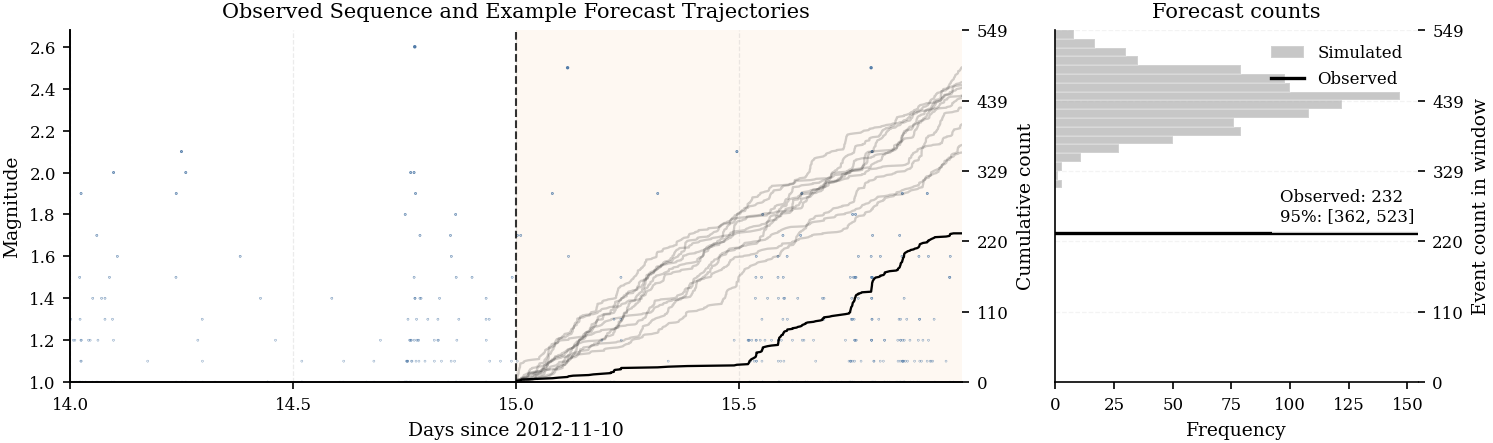

In [15]:
def generate_forecasts(model, past_seq, duration, num_samples, samples_per_batch, seed=3):
    return sample_tpp_forecasts(
        model,
        past_seq,
        duration=duration,
        num_samples=int(num_samples),
        samples_per_batch=samples_per_batch,
        seed=seed,
    )


past_seq_device = past_seq.to(DEVICE) if torch.cuda.is_available() else past_seq
all_forecasts = generate_forecasts(
    model=model,
    past_seq=past_seq_device,
    duration=FORECAST_DURATION,
    num_samples=NUM_SAMPLES,
    samples_per_batch=SAMPLES_PER_BATCH,
    seed=3,
)

zero_indices = []
for idx, fc in enumerate(all_forecasts):
    inter_times = torch.as_tensor(fc.inter_times).cpu()
    if (inter_times == 0).any():
        zero_indices.append(idx)

print('Total forecasts:', len(all_forecasts))
print('Forecasts containing zero inter_times:', len(zero_indices))
date_strs = catalog_ds.metadata['start_ts'].strftime('%Y-%m-%d') if hasattr(catalog_ds.metadata['start_ts'], 'strftime') else 'start'
visualize_trajectories(
    seq,
    all_forecasts,
    save_path=CHECKPOINT_DIR / 'all_forecasts.pdf',
    figsize=(10, 3),
    xlabel='Days since ' + date_strs,
    reset_t_nll_to_end=True,
)

## 6) RMSE, N-Test, and M-Test

Empty forecasts: 0
Forecast mag range (non-empty only): (5.581948280334473, 0.900001585483551)
Observed mag range: (2.5, 1.0)


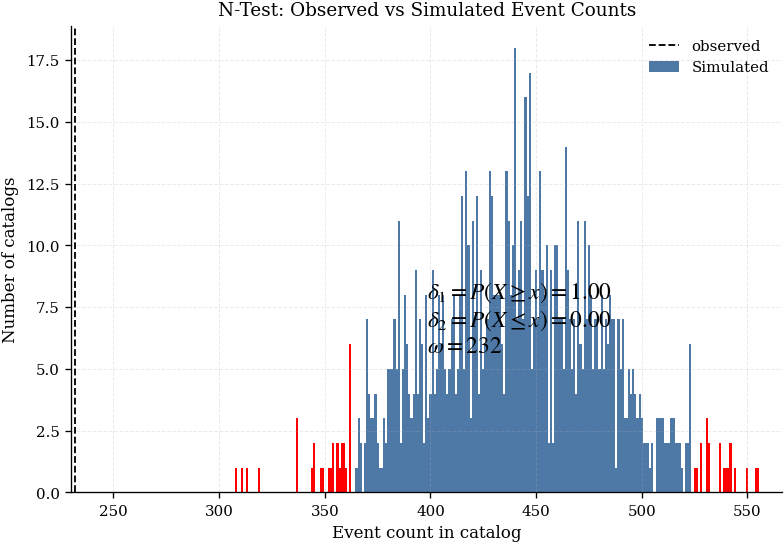

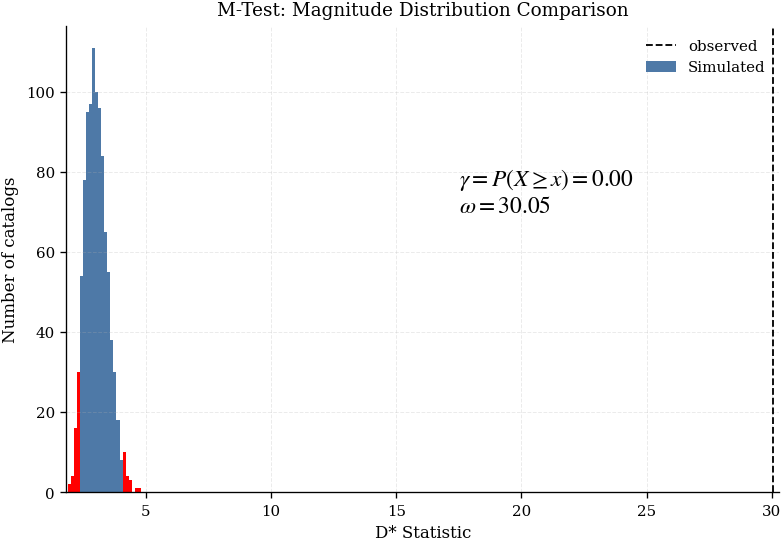

In [16]:
forecast_counts = np.array([len(fc) for fc in all_forecasts], dtype=float)
observed_count = len(observed_seq)
# rmse = float(np.sqrt(np.mean((forecast_counts - observed_count) ** 2)))
# print(f'RMSE: {rmse:.6f}')

number_test_result = catalog_tests.run_number_test_result(
    event_counts=[len(fc) for fc in all_forecasts],
    obs_count=observed_count,
    min_mw=catalog_ds.metadata['mag_completeness'],
    obs_name='observed',
    sim_name='Simulated',
    plot=False,
 )
number_test_result.plot(plot_args={'figsize': (6.8, 4.8), 'tight_layout': False})
fig_n = style_current_figure(title='N-Test: Observed vs Simulated Event Counts')
save_pub_figure(fig_n, CHECKPOINT_DIR / 'n_test.pdf')

non_empty_forecasts = [fc for fc in all_forecasts if len(fc) > 0]
empty_forecast_count = len(all_forecasts) - len(non_empty_forecasts)
print('Empty forecasts:', empty_forecast_count)

if non_empty_forecasts:
    mag_max = [fc.mag.max().item() for fc in non_empty_forecasts]
    mag_min = [fc.mag.min().item() for fc in non_empty_forecasts]
    print('Forecast mag range (non-empty only):', (max(mag_max), min(mag_min)))
else:
    print('Forecast mag range: no non-empty forecasts')

if len(observed_seq) > 0:
    print('Observed mag range:', (observed_seq.mag.max().item(), observed_seq.mag.min().item()))
else:
    print('Observed mag range: observed sequence is empty')

config_dict = {
    'min_mw': catalog_ds.metadata['mag_completeness'],
    'max_mw': 5,
    'dmw': 0.01,
}

if non_empty_forecasts:
    # quick check distribution API on one non-empty forecast
    _ = catalog_tests.compute_magnitude_distribution(non_empty_forecasts[0].mag.cpu().numpy(), **config_dict)

get_counts = functools.partial(catalog_tests.compute_magnitude_distribution, **config_dict)
result_dict = catalog_tests.magnitude_test_from_counts(
    observed_catalog=observed_seq,
    forecast_catalogs=all_forecasts,
    get_counts=lambda cat: get_counts(np.asarray(cat.mag.cpu()))[1],
    verbose=False,
    debug=False,
 )

magnitude_test_result = catalog_tests.run_magnitude_test_result(
    result_dict=result_dict,
    obs_catalog_repr='obs',
    obs_name='observed',
    sim_name='Simulated',
    plot=False,
 )
try:
    magnitude_test_result.plot(plot_args={'figsize': (6.8, 4.8), 'tight_layout': False})
    fig_m = style_current_figure(title='M-Test: Magnitude Distribution Comparison')
    save_pub_figure(fig_m, CHECKPOINT_DIR / 'm_test.pdf')
except Exception as exc:
    print(f'Skipping M-test plot due to error: {exc}')

## 7) Sliding-Window Forecast Evaluation

In [17]:
# Sliding-window settings
SLIDING_DURATION = 1
SLIDING_STEP = 1
SLIDING_QUANTILES = (2.5, 97.5)
RUN_SLIDING_WINDOW_FORECAST = True  # set to True to run the sliding window forecast, which can be time-consuming depending on settings
SLIDING_VIEW_MODE = 'zoomed'  # 'zoomed' | 'full' | 'auto'
SLIDING_CACHE_FILENAME = 'sliding_window_cache.npz'
LOAD_SLIDING_CACHE = True  # when cache exists and settings match, reuse it to skip re-sampling
FORCE_RECOMPUTE_SLIDING = False  # set True to ignore cache and regenerate cache file


/root/autodl-tmp/em_eqf/src/data/sequence.py:345: UserWarning: Found 2 zero inter-event times in the sequence. This violates fundamental assumptions of TPP models and may lead to incorrect log-likelihood values.
  warnings.warn(


/root/autodl-tmp/em_eqf/src/data/sequence.py:345: UserWarning: Found 4 zero inter-event times in the sequence. This violates fundamental assumptions of TPP models and may lead to incorrect log-likelihood values.
  warnings.warn(
/root/autodl-tmp/em_eqf/src/data/sequence.py:345: UserWarning: Found 3 zero inter-event times in the sequence. This violates fundamental assumptions of TPP models and may lead to incorrect log-likelihood values.
  warnings.warn(
/root/autodl-tmp/em_eqf/src/data/sequence.py:345: UserWarning: Found 6 zero inter-event times in the sequence. This violates fundamental assumptions of TPP models and may lead to incorrect log-likelihood values.
  warnings.warn(
/root/autodl-tmp/em_eqf/src/data/sequence.py:345: UserWarning: Found 5 zero inter-event times in the sequence. This violates fundamental assumptions of TPP models and may lead to incorrect log-likelihood values.
  warnings.warn(
/root/autodl-tmp/em_eqf/src/data/sequence.py:345: UserWarning: Found 7 zero inter-ev

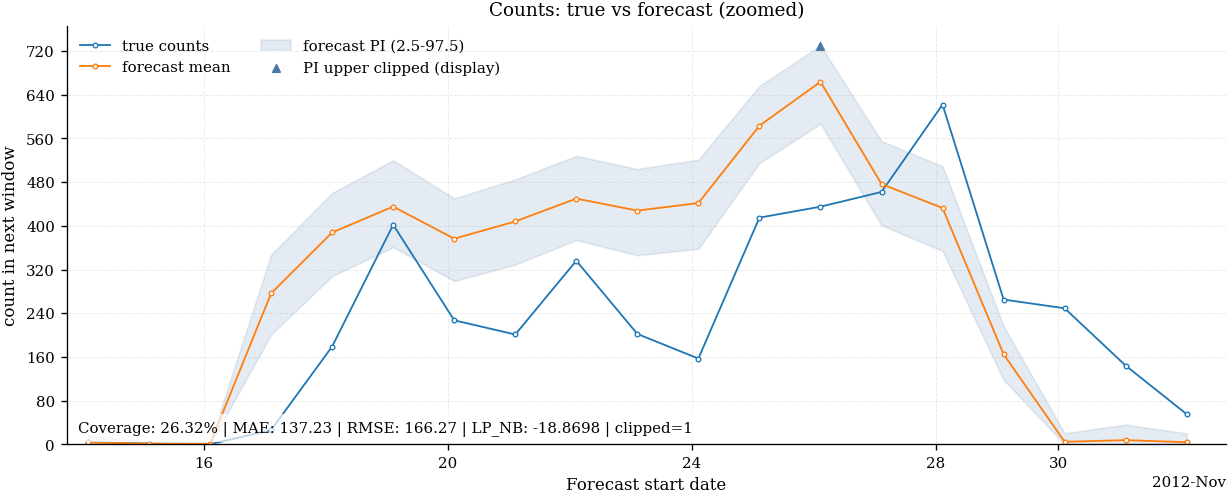

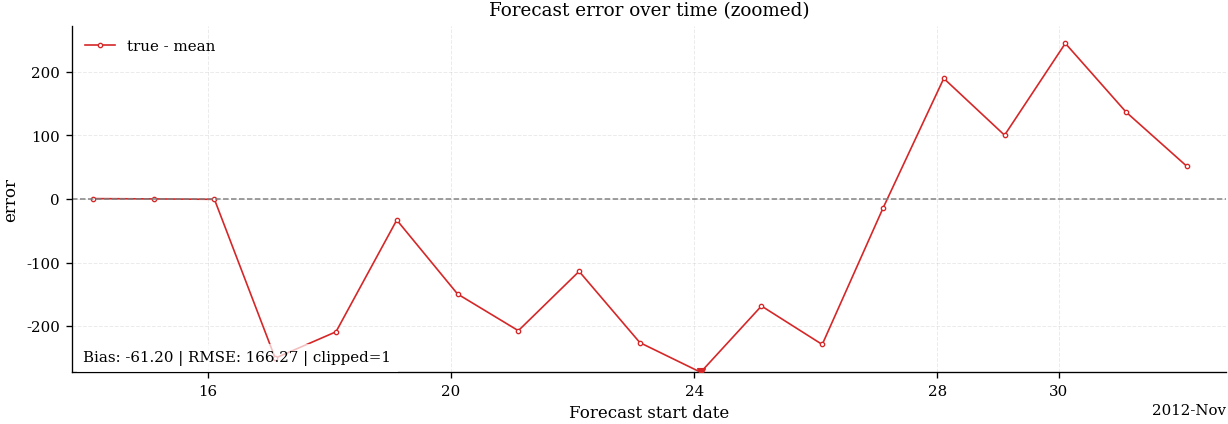

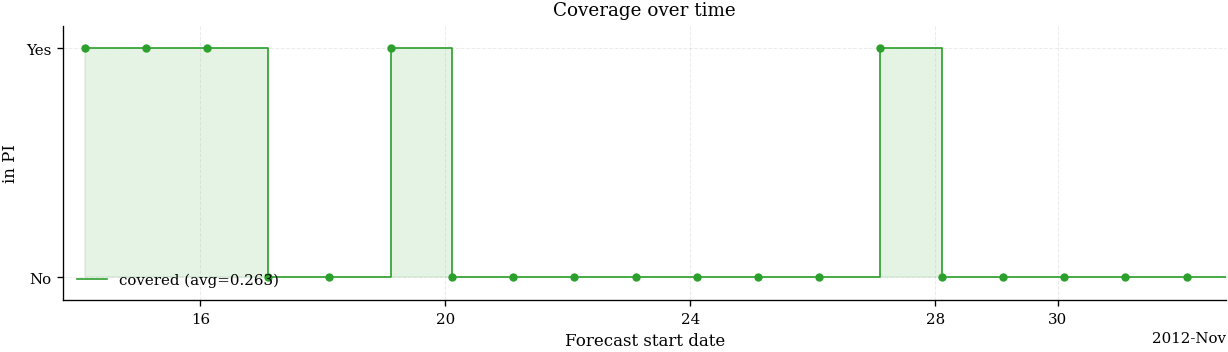

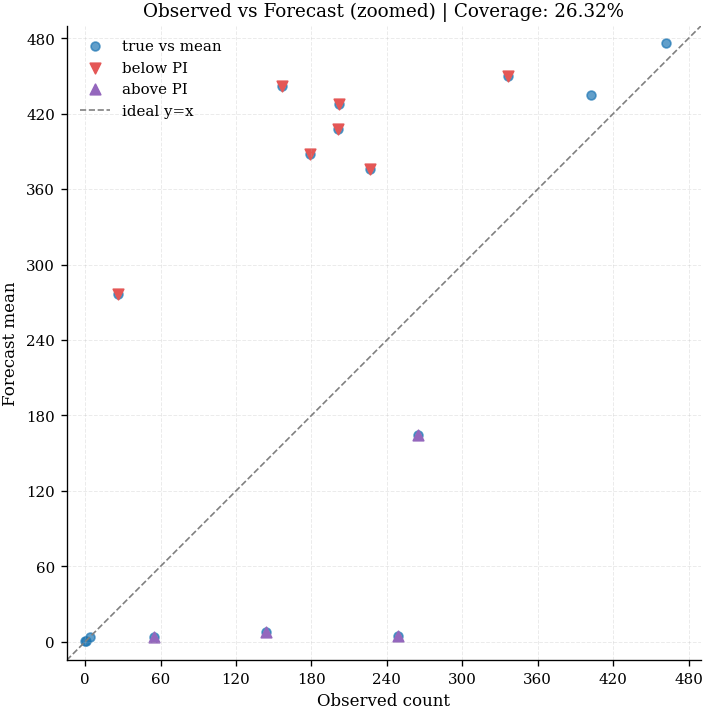

acceptance rate: 26.32%
MAE: 137.2333 | RMSE: 166.2730 | LP_NB: -18.8698
Sliding cache: computed_and_saved | /root/autodl-tmp/em_eqf/checkpoints/rtpp_20260409-223129/sliding_window_cache.npz


In [18]:
PLOT_COLORS = {
    'true': '#1f77b4',
    'mean': '#ff7f0e',
    'pi': '#4c78a8',
    'err': '#d62728',
    'covered': '#2ca02c',
    'below': '#e45756',
    'above': '#9467bd',
}

if RUN_SLIDING_WINDOW_FORECAST:
    sliding_result = evaluate_sliding_window_forecast_plots(
        model=model,
        seq=seq,
        device=DEVICE,
        catalog_ds=catalog_ds,
        checkpoint_dir=CHECKPOINT_DIR,
        sliding_duration=SLIDING_DURATION,
        sliding_step=SLIDING_STEP,
        sliding_quantiles=SLIDING_QUANTILES,
        samples_per_batch=SAMPLES_PER_BATCH,
        sliding_view_mode=SLIDING_VIEW_MODE,
        load_sliding_cache=LOAD_SLIDING_CACHE,
        force_recompute_sliding=FORCE_RECOMPUTE_SLIDING,
        sliding_cache_filename=SLIDING_CACHE_FILENAME,
        plot_colors=PLOT_COLORS,
    )

    if sliding_result.get('status') == 'empty':
        print(sliding_result['message'])
    else:
        t_forecast_list = sliding_result['t_forecast_list']
        counts_list = sliding_result['counts_list']
        q_list = sliding_result['q_list']
        mean_list = sliding_result['mean_list']
        print(f"acceptance rate: {sliding_result['coverage']:.2%}")
        lp_nb = sliding_result.get('lp_nb')
        if lp_nb is None or not np.isfinite(lp_nb):
            print(f"MAE: {sliding_result['mae']:.4f} | RMSE: {sliding_result['rmse']:.4f} | LP_NB: N/A")
        else:
            print(f"MAE: {sliding_result['mae']:.4f} | RMSE: {sliding_result['rmse']:.4f} | LP_NB: {lp_nb:.4f}")

    cache_path = sliding_result.get('sliding_cache_path')
    loaded_from_cache = sliding_result.get('sliding_loaded_from_cache')
    if cache_path is not None:
        cache_state = 'loaded' if bool(loaded_from_cache) else 'computed_and_saved'
        print(f"Sliding cache: {cache_state} | {cache_path}")

In [19]:
sliding_window_eval_metrics = {
    'status': 'ok',
    'coverage': float(sliding_result['coverage']),
    'mae': float(sliding_result['mae']),
    'rmse': float(sliding_result['rmse']),
    'lp_nb': None if lp_nb is None or not np.isfinite(lp_nb) else float(lp_nb),
    'num_windows': int(len(sliding_result['t_forecast_list'])),
    'settings': {
        'duration': float(SLIDING_DURATION),
        'step': float(SLIDING_STEP),
        'quantiles': [float(SLIDING_QUANTILES[0]), float(SLIDING_QUANTILES[1])],
        'samples_per_batch': int(SAMPLES_PER_BATCH),
        'view_mode': str(SLIDING_VIEW_MODE),
        'cache_filename': str(SLIDING_CACHE_FILENAME),
        'load_sliding_cache': bool(LOAD_SLIDING_CACHE),
        'force_recompute_sliding': bool(FORCE_RECOMPUTE_SLIDING),
    },
    'sliding_cache_path': sliding_result.get('sliding_cache_path'),
    'sliding_loaded_from_cache': bool(sliding_result.get('sliding_loaded_from_cache')),
}

metrics_path = CHECKPOINT_DIR / 'sliding_window_eval_metrics.json'
with open(metrics_path, 'w', encoding='utf-8') as f:
    json.dump(sliding_window_eval_metrics, f, ensure_ascii=False, indent=2)

print(f"Sliding-window metrics saved into checkpoint: {metrics_path}")

Sliding-window metrics saved into checkpoint: /root/autodl-tmp/em_eqf/checkpoints/rtpp_20260409-223129/sliding_window_eval_metrics.json


In [20]:
sliding_window_eval_metrics

{'status': 'ok',
 'coverage': 0.2631578947368421,
 'mae': 137.23326315789473,
 'rmse': 166.27300206651267,
 'lp_nb': -18.869774239069606,
 'num_windows': 19,
 'settings': {'duration': 1.0,
  'step': 1.0,
  'quantiles': [2.5, 97.5],
  'samples_per_batch': 1000,
  'view_mode': 'zoomed',
  'cache_filename': 'sliding_window_cache.npz',
  'load_sliding_cache': True,
  'force_recompute_sliding': False},
 'sliding_cache_path': '/root/autodl-tmp/em_eqf/checkpoints/rtpp_20260409-223129/sliding_window_cache.npz',
 'sliding_loaded_from_cache': False}

In [21]:
import numpy as np

model.eval()
grid_device = getattr(model, 'device', DEVICE)
test_grid = torch.linspace(0, 1, 200, device=grid_device)

pred_dist = None
if hasattr(model, 'bg_model') and hasattr(model.bg_model, 'svgp'):
    with torch.no_grad():
        pred_dist = model.bg_model.svgp(test_grid.unsqueeze(-1))
elif hasattr(model, 'bg_model') and hasattr(model.bg_model, 'gp_model'):
    try:
        with torch.no_grad():
            pred_dist = model.bg_model.gp_model(test_grid.unsqueeze(-1))
    except Exception as exc:
        print(f'Skip latent GP plot: unable to query gp_model ({exc}).')
else:
    print("Skip latent GP plot: bg_model has no 'svgp' or 'gp_model' interface.")

if pred_dist is not None:
    mean = pred_dist.mean.detach().cpu().numpy()
    var = pred_dist.variance.detach().cpu().numpy()
    std = np.sqrt(var)

    latent_idx = 0
    x = test_grid.detach().cpu().numpy().reshape(-1)
    if mean.ndim == 2:
        y = mean[:, latent_idx]
        y_std = std[:, latent_idx]
    else:
        y = mean.reshape(-1)
        y_std = std.reshape(-1)

    fig, ax = plt.subplots(figsize=(8.8, 4.4))
    ax.plot(
        x,
        y,
        color='#1f77b4',
        linewidth=1.2,
        label=f'Latent Mean (dim={latent_idx})',
    )
    ax.fill_between(
        x,
        y - 2 * y_std,
        y + 2 * y_std,
        alpha=0.18,
        color='#4c78a8',
        label='+- 2 StdDev',
    )
    ax.set_xlabel('Normalized Time')
    ax.set_ylabel('Latent Value')
    ax.set_title('Latent Background Process Posterior')
    ax.grid(True, alpha=0.25, linestyle='--', linewidth=0.6)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.legend(frameon=False)
    fig.tight_layout()
    save_pub_figure(fig, CHECKPOINT_DIR / 'latent_background_posterior.png')
    plt.show()


Skip latent GP plot: bg_model has no 'svgp' or 'gp_model' interface.
